# 01 - Import & Exploratory Data Analysis - CSE-CIC-IDS2018

In [1]:
DATASET = "cic2018"
FT_ROOT = None
ROWS_PER_FILE_2018 = 200_000
RAW_SOURCE = None
SMOKE_SAMPLE_ROWS = None
REBUILD = False

In [2]:
import sys
from pathlib import Path

def _find_nb_common():
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for c in (cand, cand / "notebooks"):
            if (c / "nb_common.py").exists():
                return c
    raise FileNotFoundError("nb_common.py not found relative to " + str(Path.cwd()))
sys.path.insert(0, str(_find_nb_common()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nb_common as nbc
from ids import config
from ids.schema import CANONICAL_COLUMNS, LABEL_COLUMN
from ids.data.loaders import read_full, read_and_sample
from ids.data.unify import unify_2017, unify_2018, concat_unified
from ids.data.labels import normalize_labels

if SMOKE_SAMPLE_ROWS and FT_ROOT is None:
    raise ValueError("smoke runs must set FT_ROOT to a scratch directory")

P = nbc.ft_paths(DATASET, FT_ROOT)
log = nbc.setup_logging(P.logs / "01_load_and_eda.log", "nb01")
log.info("dataset=%s | random_state=%d | artifacts -> %s", DATASET, config.RANDOM_STATE, P.root)
RAW_PATH = P.data / "raw_unified.parquet"

2026-07-06 09:03:11,795 INFO nb01: dataset=cic2018 | random_state=42 | artifacts -> /Users/MAC/Projects/IDS/backend/artifacts/ft40/cic2018


## 1. Import the raw dataset

In [3]:
if RAW_PATH.exists() and not REBUILD:
    with nbc.timed(log, f"load cached {RAW_PATH.name}"):
        raw = pd.read_parquet(RAW_PATH)
else:
    if RAW_SOURCE:
        with nbc.timed(log, f"load pre-built unified parquet {RAW_SOURCE}"):
            raw = pd.read_parquet(RAW_SOURCE)
    else:
        src_dir = config.CIC2017_DIR if DATASET == "cic2017" else config.CIC2018_DIR
        csvs = sorted(src_dir.glob("*.csv"))
        log.info("importing %d raw CSV files from %s", len(csvs), src_dir)
        frames = []
        for csv_path in csvs:
            with nbc.timed(log, f"read {csv_path.name}"):
                if DATASET == "cic2017":
                    df = unify_2017(read_full(csv_path))
                else:
                    df = unify_2018(read_and_sample(
                        csv_path, rows_per_file=ROWS_PER_FILE_2018,
                        random_state=config.RANDOM_STATE))
            log.info("%s -> %d rows", csv_path.name, len(df))
            frames.append(df)
        raw = concat_unified(frames)
        raw[LABEL_COLUMN] = normalize_labels(raw[LABEL_COLUMN])

    if SMOKE_SAMPLE_ROWS:
        counts = raw[LABEL_COLUMN].value_counts()
        raw = raw[raw[LABEL_COLUMN].isin(counts[counts >= 200].index)]
        frac = min(1.0, SMOKE_SAMPLE_ROWS / len(raw))
        raw = (raw.groupby(LABEL_COLUMN, group_keys=False, observed=True)
                  .apply(lambda g: g.sample(frac=frac, random_state=config.RANDOM_STATE))
                  .reset_index(drop=True))
        log.warning("SMOKE RUN: subsampled to %d rows — NOT study artifacts", len(raw))

    raw.to_parquet(RAW_PATH, index=False)
    log.info("saved %s (%d rows x %d cols)", RAW_PATH, len(raw), raw.shape[1])

raw.shape

2026-07-06 09:03:11,805 INFO nb01: importing 10 raw CSV files from /Users/MAC/Projects/IDS/datasets/CSE-CIC-IDS2018
2026-07-06 09:03:11,806 INFO nb01: START read 02-14-2018.csv
2026-07-06 09:03:19,449 INFO ids.data.loaders: 02-14-2018.csv: sampled 200001 / 1048575 rows
2026-07-06 09:03:19,531 INFO nb01: END   read 02-14-2018.csv (7.7s)
2026-07-06 09:03:19,532 INFO nb01: 02-14-2018.csv -> 200001 rows
2026-07-06 09:03:19,532 INFO nb01: START read 02-15-2018.csv
2026-07-06 09:03:26,951 INFO ids.data.loaders: 02-15-2018.csv: sampled 200001 / 1048575 rows
2026-07-06 09:03:27,026 INFO nb01: END   read 02-15-2018.csv (7.5s)
2026-07-06 09:03:27,027 INFO nb01: 02-15-2018.csv -> 200001 rows
2026-07-06 09:03:27,027 INFO nb01: START read 02-16-2018.csv
2026-07-06 09:03:40,208 INFO ids.data.loaders: 02-16-2018.csv: sampled 200002 / 1048575 rows
2026-07-06 09:03:41,162 INFO nb01: END   read 02-16-2018.csv (14.1s)
2026-07-06 09:03:41,162 INFO nb01: 02-16-2018.csv -> 200002 rows
2026-07-06 09:03:41,16

(1999987, 78)

## 2. Size, dtypes, memory

In [4]:
overview = {
    "dataset": DATASET,
    "rows": int(len(raw)),
    "n_features": len(CANONICAL_COLUMNS),
    "columns": int(raw.shape[1]),
    "memory_mb": round(float(raw.memory_usage(deep=True).sum()) / 1e6, 1),
    "dtype_counts": raw.dtypes.astype(str).value_counts().to_dict(),
    "n_duplicate_rows": int(raw.duplicated().sum()),
}
nbc.save_json(overview, P.eda / "overview.json")
log.info("overview: %s", overview)
overview

2026-07-06 09:06:13,772 INFO nb01: overview: {'dataset': 'cic2018', 'rows': 1999987, 'n_features': 77, 'columns': 78, 'memory_mb': 1362.0, 'dtype_counts': {'float64': 77, 'object': 1}, 'n_duplicate_rows': 403318}


{'dataset': 'cic2018',
 'rows': 1999987,
 'n_features': 77,
 'columns': 78,
 'memory_mb': 1362.0,
 'dtype_counts': {'float64': 77, 'object': 1},
 'n_duplicate_rows': 403318}

## 3. Class (label) distribution

2026-07-06 09:06:13,834 INFO nb01: 15 classes; imbalance ratio max/min = 95213


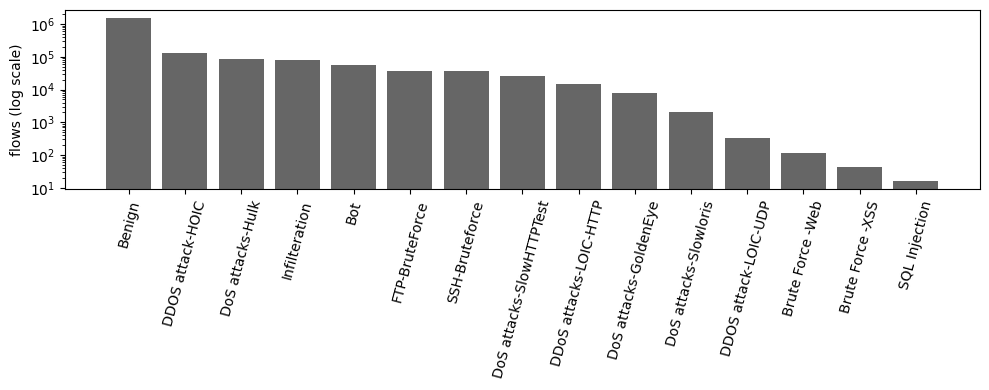

,label,count,pct
0,Benign,1523412,76.1711
1,DDOS attack-HOIC,130847,6.5424
2,DoS attacks-Hulk,88103,4.4052
3,Infilteration,78677,3.9339
4,Bot,54587,2.7294
5,FTP-BruteForce,36881,1.8441
6,SSH-Bruteforce,35780,1.7890
7,DoS attacks-SlowHTTPTest,26682,1.3341
8,DDoS attacks-LOIC-HTTP,14499,0.7250
9,DoS attacks-GoldenEye,7917,0.3959


In [5]:
label_dist = (raw[LABEL_COLUMN].value_counts()
              .rename_axis("label").reset_index(name="count"))
label_dist["pct"] = (100 * label_dist["count"] / len(raw)).round(4)
label_dist.to_csv(P.eda / "label_distribution.csv", index=False)
log.info("%d classes; imbalance ratio max/min = %.0f",
         len(label_dist), label_dist["count"].max() / label_dist["count"].min())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(label_dist["label"], label_dist["count"], color="0.4")
ax.set_yscale("log")
ax.set_ylabel("flows (log scale)")
ax.tick_params(axis="x", rotation=75)
fig.tight_layout()
fig.savefig(P.eda / "plots" / "label_distribution.png", dpi=150)
plt.show()
label_dist

## 4. Data quality: missing, infinite, zero, negative values per feature

In [6]:
feat = raw[CANONICAL_COLUMNS]
quality = pd.DataFrame({
    "n_nan": feat.isna().sum(),
    "n_inf": np.isinf(feat.to_numpy()).sum(axis=0),
    "n_zero": (feat == 0).sum(),
    "n_negative": (feat < 0).sum(),
})
quality.to_csv(P.eda / "feature_quality.csv")
zero_variance = feat.columns[feat.nunique() <= 1].tolist()
dq = {
    "total_nan": int(quality["n_nan"].sum()),
    "total_inf": int(quality["n_inf"].sum()),
    "features_with_nan": quality.index[quality["n_nan"] > 0].tolist(),
    "features_with_inf": quality.index[quality["n_inf"] > 0].tolist(),
    "zero_variance_features": zero_variance,
}
nbc.save_json(dq, P.eda / "data_quality.json")
log.info("NaN cells=%d | inf cells=%d | zero-variance features=%s",
         dq["total_nan"], dq["total_inf"], zero_variance or "none")
quality[(quality[["n_nan", "n_inf"]].sum(axis=1)) > 0]

2026-07-06 09:06:15,834 INFO nb01: NaN cells=6550 | inf cells=14266 | zero-variance features=['bwd_psh_flags', 'bwd_urg_flags', 'fwd_byts_b_avg', 'fwd_pkts_b_avg', 'fwd_blk_rate_avg', 'bwd_byts_b_avg', 'bwd_pkts_b_avg', 'bwd_blk_rate_avg']


,n_nan,n_inf,n_zero,n_negative
flow_byts_s,6550,3858,693167,0
flow_pkts_s,0,10408,0,2


## 5. Descriptive statistics (all 77 features)

In [7]:
desc = feat.describe().T
desc.to_csv(P.eda / "describe.csv")
log.info("saved describe.csv (%d features)", len(desc))
desc.head(15)

/Users/MAC/Projects/IDS/backend/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/MAC/Projects/IDS/backend/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


2026-07-06 09:06:19,447 INFO nb01: saved describe.csv (77 features)


,count,mean,std,min,25%,50%,75%,max
dst_port,1999987.0,1.027071e+04,1.975245e+04,0.000000e+00,53.0,80.000000,3.389000e+03,6.553500e+04
flow_duration,1999987.0,1.095863e+07,4.945025e+08,-6.420520e+11,465.0,13922.000000,2.583446e+06,1.200000e+08
tot_fwd_pkts,1999987.0,2.636348e+01,1.641015e+03,1.000000e+00,1.0,2.000000,5.000000e+00,3.096290e+05
tot_bwd_pkts,1999987.0,5.941271e+00,1.811914e+02,0.000000e+00,0.0,1.000000,4.000000e+00,1.210910e+05
totlen_fwd_pkts,1999987.0,1.185566e+03,1.198677e+05,0.000000e+00,0.0,42.000000,5.530000e+02,1.443918e+08
totlen_bwd_pkts,1999987.0,4.311114e+03,2.488204e+05,0.000000e+00,0.0,90.000000,3.760000e+02,1.561992e+08
fwd_pkt_len_max,1999987.0,2.164734e+02,3.226897e+02,0.000000e+00,0.0,40.000000,3.260000e+02,3.436800e+04
fwd_pkt_len_min,1999987.0,1.015852e+01,2.606309e+01,0.000000e+00,0.0,0.000000,0.000000e+00,1.460000e+03
fwd_pkt_len_mean,1999987.0,5.294263e+01,6.565533e+01,0.000000e+00,0.0,35.555556,7.872475e+01,7.188268e+03
fwd_pkt_len_std,1999987.0,7.961730e+01,1.287312e+02,0.000000e+00,0.0,0.000000,1.377806e+02,6.051453e+03


## 6. Feature correlation

2026-07-06 09:06:21,269 INFO nb01: pairs with |r| > 0.95: 46


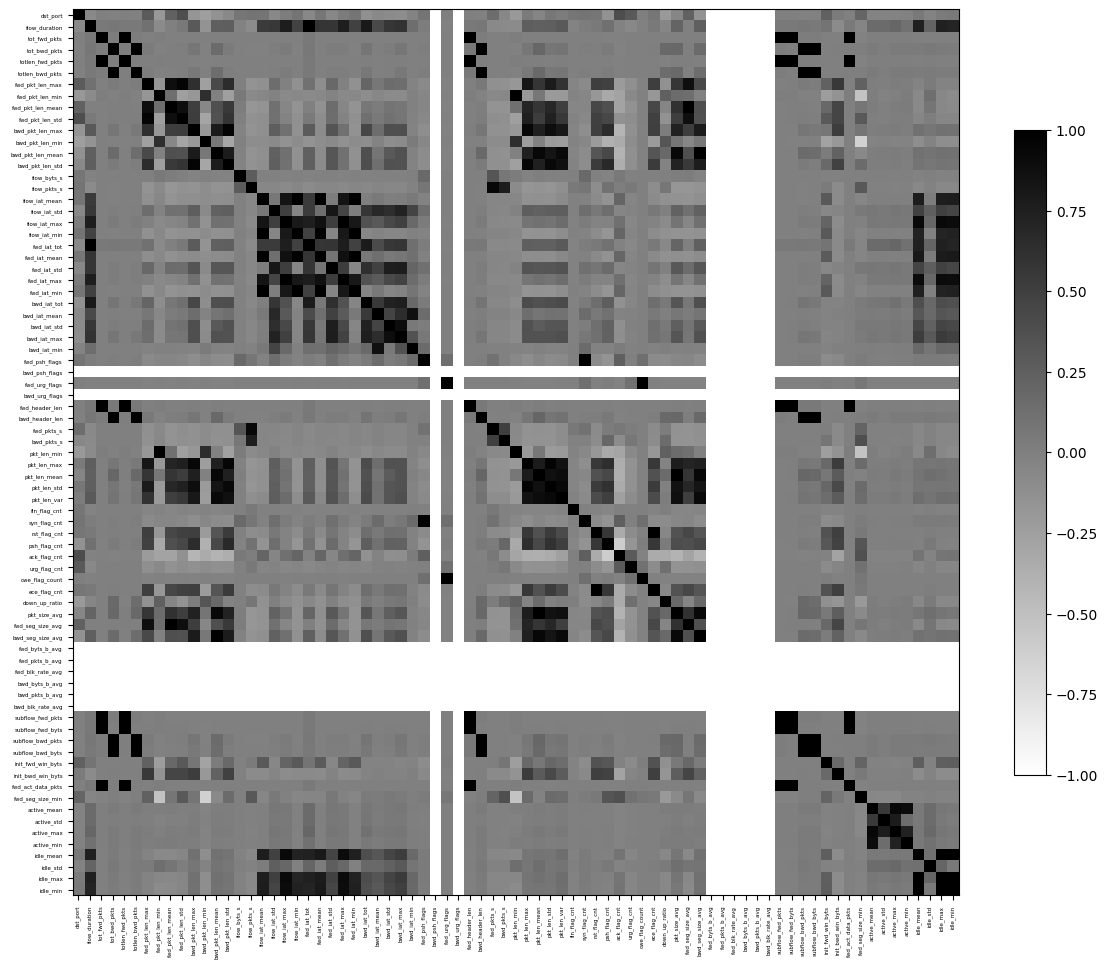

46 feature pairs with |r| > 0.95


In [8]:
sample = feat.sample(n=min(200_000, len(feat)), random_state=config.RANDOM_STATE)
corr = sample.replace([np.inf, -np.inf], np.nan).corr()
corr.to_csv(P.eda / "correlation_matrix.csv")

upper = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
high_pairs = [(a, b, round(float(upper.loc[a, b]), 3))
              for a in upper.index for b in upper.columns
              if pd.notna(upper.loc[a, b]) and abs(upper.loc[a, b]) > 0.95]
log.info("pairs with |r| > 0.95: %d", len(high_pairs))
nbc.save_json({"threshold": 0.95, "pairs": high_pairs}, P.eda / "high_correlation_pairs.json")

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="gray_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, fontsize=4, rotation=90)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=4)
fig.colorbar(im, shrink=0.7)
fig.tight_layout()
fig.savefig(P.eda / "plots" / "correlation_heatmap.png", dpi=200)
plt.show()
print(f"{len(high_pairs)} feature pairs with |r| > 0.95")

In [9]:
log.info("notebook 01 complete — artifacts in %s", P.eda)
sorted(str(p.relative_to(P.root)) for p in P.eda.rglob("*") if p.is_file())

2026-07-06 09:06:21,884 INFO nb01: notebook 01 complete — artifacts in /Users/MAC/Projects/IDS/backend/artifacts/ft40/cic2018/eda


['eda/correlation_matrix.csv',
 'eda/data_quality.json',
 'eda/describe.csv',
 'eda/feature_quality.csv',
 'eda/high_correlation_pairs.json',
 'eda/label_distribution.csv',
 'eda/overview.json',
 'eda/plots/correlation_heatmap.png',
 'eda/plots/label_distribution.png']